In [2]:

import os
%load_ext autoreload
%autoreload 2
from pathlib import Path
from acados_template import AcadosOcp
from commom_utils.ode_system import ODESystem, check_system_ok, MHESyntheticDataGenerator
import numpy as np
import matplotlib.pyplot as plt

from commom_utils.systems import *
from mhe.mhe_base_model_interface import MheModel, MheCogeGenerator
from mhe.params import MheParams
from mhe.mhe_utils import MheEstimationData, run_mhe_estimation, plot_mhe_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
from mhe.params import MheParams

# Общие параметры
mhe_horizont = 300
ts = 0.02


def sinus(t):
    u  = jnp.sin(0.3*t)
    # if(t < 15):
    #     u = 0
    return [u]

def get_input_signals_bycicle(t):
    import math
    w = 0.7
    steering = 0.8 * math.cos(t * 0.25 * w) * math.sin(w * t)
    if t < 25:
        steering = 0
    v = 10.0
    return [v, steering]

# Словарь конфигураций
configs = {
    "MassSpringDamper": {
        "system_class": MassSpringDamper,
        "system_args": [],  # аргументы конструктора (если есть)
        "c0": np.array([1.0, 10.0]),
        "theta_true": np.array([3, 1.0]),
        "measurements_residual_r": np.diag([1, 1]),
        "state_prior_q0": np.diag([1, 1]),
        "noise_peanlty_w": np.eye(2) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]] * 2,
        "bounds_state": [[-np.inf, np.inf]] * 2,
        "bounds_param": [[-2000, 2000]] * 2,
    },
    "KinematicBycicle": {
        "system_class": KinematicBycicle,
        "get_input_signals": lambda t: get_input_signals_bycicle(t),
        "system_args": [2.65],  # wheelbase
        "c0": np.array([0]),
        "theta_true": np.array([0.05, np.deg2rad(-5.0)]),
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": np.diag([1]),
        "noise_peanlty_w": np.eye(1) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]],
        "bounds_state": [[-np.inf, np.inf]],
        "bounds_param": [np.deg2rad([-5, 5]), [-1, 1]],
    },
    "Integrator": {
        "system_class": Integrator,
        "system_args": [],
        "c0": np.array([0.0, 0.0]),
        "theta_true": np.array([1.0]),
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": np.diag([1, 1]),
        "noise_peanlty_w": np.eye(2) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]] * 2,
        "bounds_state": [[-1e5, 1e5]] * 2,
        "bounds_param": [[0, 20]],
    },
    "DelaySystem": {
        "system_class": DelaySystem,
        "get_input_signals": lambda t: sinus(t),
        "system_args": [2],  # порядок (1 = Паде 1‑го порядка)
        "c0": np.array(2*[0.0]),  # начальное состояние для одного состояния
        "theta_true": np.array([0.4]),
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": 0*np.diag(2*[1]),
        "noise_peanlty_w": np.eye(2) * 1e3,
        "fim_scaler": 0.1,
        "bounds_noise": 2*[[-0.01, 0.01]],
        "bounds_state": 2*[[-1e5, 1e5]],
        "bounds_param": [[0, 20]],
    }
}

# Выбор модели (измените ключ)
model_key = "KinematicBycicle"   # например, "MassSpringDamper", "KinematicBycicle", "Integrator"
cfg = configs[model_key]


class CustomSystem(cfg["system_class"]):
    pass

if "get_input_signals" in cfg:
    def get_input_signals(self, t):
        return cfg["get_input_signals"](t)
    CustomSystem.get_input_signals = get_input_signals

# Создаём систему
system = CustomSystem(*cfg["system_args"])

# Начальное состояние (c0)
c0 = cfg["c0"]

# Истинные параметры 
theta_true = cfg["theta_true"]

# Параметры MHE
mhe_params = MheParams(
    dt=ts,
    mhe_horizont=mhe_horizont,
    state_prior_q0=cfg["state_prior_q0"],
    noise_peanlty_w=cfg["noise_peanlty_w"],
    measurements_residual_r=cfg["measurements_residual_r"],
    bounds_noise=cfg["bounds_noise"],
    bounds_state=cfg["bounds_state"],
    bounds_param=cfg["bounds_param"],
    fim_scaler=cfg["fim_scaler"]
)

mhe_params.print()

dt: 0.02
mhe_horizont: 300
state_prior_q0: [[0 0]
 [0 0]]
noise_peanlty_w: [[1000.    0.]
 [   0. 1000.]]
measurements_residual_r: [[1]]
bounds_param: [[0, 20]]
bounds_state: [[-100000.0, 100000.0], [-100000.0, 100000.0]]
bounds_noise: [[-0.01, 0.01], [-0.01, 0.01]]
fim_scaler: 0.1


In [4]:
class MyCogeGenerator(MheCogeGenerator):
    def __init__(self):
        super().__init__(system, mhe_params,  Path(os.getcwd())/'mhe/tmp_generated', 'kinematik_mhe')

    def modify_ocp_problem(self, ocp_mhe: AcadosOcp) -> AcadosOcp:
        ocp_mhe.solver_options.print_level = 1
        ocp_mhe.solver_options.nlp_solver_stats_level = 2

        # ocp_mhe.solver_options.integrator_type = 'IRK'
        # ocp_mhe.solver_options.sim_method_num_stages = 3
        # ocp_mhe.solver_options.sim_method_newton_tol = 1e-9
        # ocp_mhe.solver_options.sim_method_newton_iter = 10

        # # В настройках решателя
        # ocp_mhe.solver_options.nlp_solver_type = 'SQP'
        # ocp_mhe.solver_options.nlp_solver_max_iter = 200
        # ocp_mhe.solver_options.levenberg_marquardt = 1e-6
        # ocp_mhe.solver_options.globalization = 'FIXED_STEP'
        # ocp_mhe.solver_options.globalization_fixed_step_length = 0.9
        # ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-4   # временно ослабить
        # ocp_mhe.solver_options.nlp_solver_tol_eq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_ineq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_comp = 1e-4

        # ocp_mhe.solver_options.nlp_solver_max_iter =120
        # #ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-3
        # ocp_mhe.solver_options.nlp_solver_type = 'SQP'
        # ocp_mhe.solver_options.nlp_solver_max_iter = 200
        # ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_eq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_ineq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_comp = 1e-4
        # ocp_mhe.solver_options.hessian_approx = 'GAUSS_NEWTON'
        # ocp_mhe.solver_options.globalization = 'FIXED_STEP'
        # ocp_mhe.solver_options.globalization_fixed_step_length = 0.9
        # ocp_mhe.solver_options.levenberg_marquardt = 1e-6
        # ocp_mhe.solver_options.qp_solver = 'PARTIAL_CONDENSING_HPIPM'
        # ocp_mhe.solver_options.hpipm_options = {
        #     'scale': 1,
        #     'scale_ux': 1,
        #     'iter_max': 1000,
        #     'tol': 1e-6,
        #     'reg_epsilon': 1e-6,
        #     'reg_epsilon_s': 1e-6,
        # }
        return ocp_mhe

generator = MyCogeGenerator()

assert check_system_ok(system) == True

acados_solver_mhe = generator.generate_code()

INFO:2026-04-17 11:16:38,758:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-04-17 11:16:38,758 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Please export ACADOS_SOURCE_DIR to avoid this warning.
[-100000. -100000.       0.]
[1.e+05 1.e+05 2.e+01]
[0 1 2]
kinematik_mhe
1 2

got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost, this coincides with the Gauss-Newton Hessian.
Note: There is also the option to use the external cost module with a numerical Hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom Hessian approximation (see `cost_expr_ext_cost_custom_hess`).


got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost

In [5]:
# Create the generator

simulation_system = system# KinematicBycicleActuator(wheelbase=2.65, kp = 200, kv = 10)


data_gen = MHESyntheticDataGenerator(simulation_system, sigma=0.0)

# Parameters
t0 = 0
T_f = mhe_params.dt * mhe_params.mhe_horizont          
N_measurement = mhe_params.mhe_horizont           
overlap_points = 1#int(N_measurement*0.5)
num_windows = 10                                    # number of overlapping windows


# Generate exact windows
t_windows, u_windows, meas_windows, full_windows = data_gen.generate_sliding_windows_exact(
    c0, theta_true, t0, T_f, num_windows, N_measurement + 1, overlap_points=overlap_points
)

# Check the time span of the first window
print(f"Window 0: start={t_windows[0][0]:.6f}, end={t_windows[0][-1]:.6f}, span={t_windows[0][-1]-t_windows[0][0]:.6f}")
# This should equal T_f
def get_window(i):
    return t_windows[i], u_windows[i][:], meas_windows[i]

Window 0: start=0.000000, end=6.000000, span=6.000000


/tmp/ipykernel_288812/636795376.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


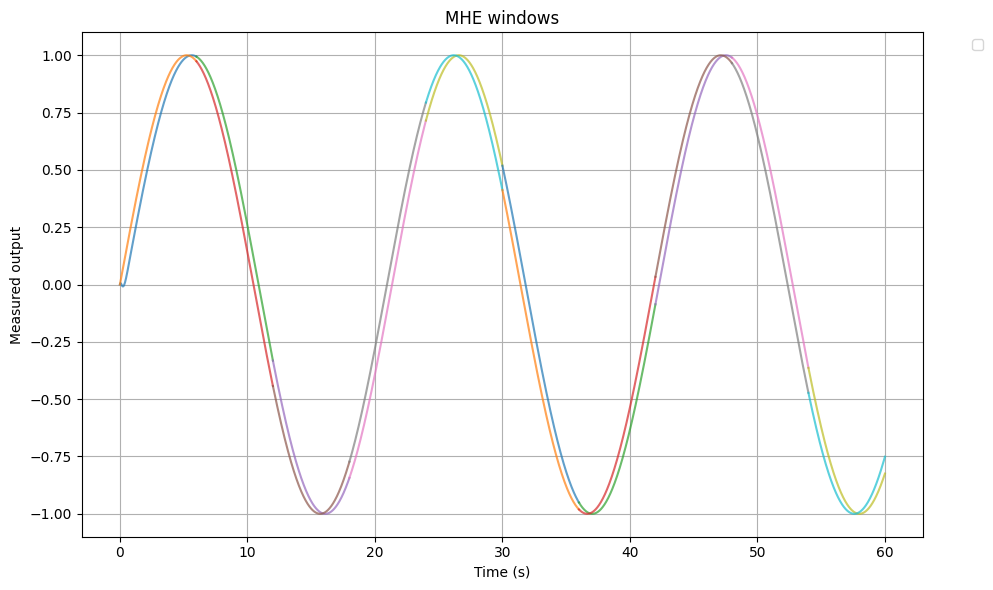

In [6]:
plt.figure(figsize=(10, 6))
for i in range(0, num_windows):
    t, simU, simY = get_window(i)
    plt.plot(t, simY[:, :3], alpha=0.7)
    plt.plot(t, simU[:, :3], alpha=0.7)

plt.xlabel('Time (s)')
plt.ylabel('Measured output')
plt.title('MHE windows')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
initial_theta = theta_true*0.2


results = run_mhe_estimation(
    mhe_model=generator.get_model(),
    acados_solver_factory= acados_solver_mhe,   # you might pass a pre‑created solver or a factory
    get_window_func=get_window,
    overlap_points=overlap_points,
    initial_theta = initial_theta,
    mhe_params=mhe_params,
    num_windows=num_windows,
    ridge_reg = 1e-0,
    R_inv=mhe_params.measurements_residual_r,
    forgetting_factor = 0.01,
    compute_advanced_fim = True,
    plot=0   # set to True if you want live plots
)

MHE windows:   0%|          | 0/10 [00:00<?, ?window/s]

2026-04-17 11:16:42,923 - WARNING - Window 0: acados returned status 2. Skipping this window.
MHE windows:  10%|█         | 1/10 [00:00<00:03,  2.87window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   4.9962e-03   1.1996e+03   0.0000e+00   0.0000e+00         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   2.0684e-02   1.6775e+00   0.0000e+00   6.9427e-10         0         3   1.88e+00   1.00e-06  1.00e+00    
     2   2.2061e-01   5.9943e+00   0.0000e+00   1.4592e-09         0         6   9.24e+00   1.00e-06  1.00e+00    
     3   8.3979e+05   1.8945e+03   0.0000e+00   2.8607e-07         0        13   1.03e+03   1.00e-06  1.00e+00    
     4   8.3971e+05   1.3836e-08   0.0000e+00   6.7181e-07         0        28   1.02e+03   1.00e-06  1.00e+00    
     5   5.5220e+05   2.7218e+02   0.0000e+00   5.9194e-08         0         6   2.00e+01   1.00e-06  1.00e+00    
     6   6.5629e-01   7.3996e+01   0.0000e+00   8.8485e-10         0         7   7.56e+01   1.00e-06  1.00e+00    
     7   9.4141e-02   1.7849e+01   0.0000e+00   6.3575e-11         0         8   

2026-04-17 11:16:43,175 - WARNING - Window 1: acados returned status 4. Skipping this window.
MHE windows:  20%|██        | 2/10 [00:00<00:02,  3.42window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   8.3552e-01   3.6206e+02   0.0000e+00   1.0000e-11         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   2.6816e+00   3.5467e+01   0.0000e+00   8.6243e-08         0         5   2.70e+01   1.00e-06  1.00e+00    
     2   4.4985e-02   1.0758e+01   0.0000e+00   5.8017e-08         0         6   4.51e+01   1.00e-06  1.00e+00    
     3   3.6564e-02   6.0618e+00   0.0000e+00   3.0604e-09         0         6   1.61e+01   1.00e-06  1.00e+00    
     4   9.0354e-03   7.1959e+00   0.0000e+00   1.3959e-08         0         5   5.49e+00   1.00e-06  1.00e+00    
4	9.035393e-03	7.195912e+00	0.000000e+00	1.395943e-08.



QP solver returned error status 3 (ACADOS_MINSTEP) in SQP iteration 5, QP iteration 32.


...

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   8.8433e+03   6.2789e+01   0.0000e+00   1.0013e-11         0         0   0.00e+00   0.00e+00  1.00e+00    
0	8.843272e+03	6.278911e+01	0.000000e+00	1.001296e-11.



QP solver returned error status 3 (ACADOS_MINSTEP) in SQP iteration 1, QP iteration 7.


2026-04-17 11:16:45,238 - WARNING - Window 8: acados returned status 4. Skipping this window.
MHE windows:  90%|█████████ | 9/10 [00:02<00:00,  3.75window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   8.8442e+03   6.2787e+01   0.0000e+00   1.0013e-11         0         0   0.00e+00   0.00e+00  1.00e+00    
0	8.844156e+03	6.278723e+01	0.000000e+00	1.001296e-11.



QP solver returned error status 3 (ACADOS_MINSTEP) in SQP iteration 1, QP iteration 7.


2026-04-17 11:16:45,462 - WARNING - Window 9: acados returned status 4. Skipping this window.
MHE windows: 100%|██████████| 10/10 [00:02<00:00,  3.46window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   8.8442e+03   6.2790e+01   0.0000e+00   1.0013e-11         0         0   0.00e+00   0.00e+00  1.00e+00    
0	8.844211e+03	6.279013e+01	0.000000e+00	1.001296e-11.



QP solver returned error status 3 (ACADOS_MINSTEP) in SQP iteration 1, QP iteration 7.


In [7]:
results[-1].param_est

array([0.38019625])

In [8]:
plot_mhe_results(results, overlap=overlap_points,
                 initial_params=None,
                 theta_true=theta_true,   # your true parameter array
                 plot_states=True,
                 plot_params=True,
                 plot_eigvals=True,
                 plot_noise=False,
                 plot_cost=True,
                 plot_iter=True,
                 plot_status=True,
                 figsize=(15, 18))   # slightly larger to accommodate taller first plot

No results to plot.


In [10]:
initial_theta = theta_true
t_batch, simU, simY = get_window(10)
unknown_state_length = 0


initial_x0 = np.hstack((simY[0]))
print(initial_x0)
R_inv = np.diag(1*[1])
mhe_model=generator.get_model()
F = mhe_model.compute_fim(simY.shape[0], mhe_params.dt, simU, initial_x0, initial_theta, R_inv)
F
#set_mhe_solver(mhe_model, acados_solver_mhe, simY, simU, initial_x0, initial_theta, mhe_params.dt, N_measurement, unknown_state_length, R_inv)

[-1.23968548]


array([[ 1361.03263992,  8277.43431679],
       [ 8277.43431679, 52041.04294695]])

In [11]:
simU.shape

(501, 1)